In [ ]:
import pandas as pd


A = pd.read_csv("office_A.csv")
B = pd.read_csv("office_B.csv")

In [ ]:
# Check if both datasets have the exact same columns (names + order) before merging.
cols_A = list(A.columns)
cols_B = list(B.columns)

print("Same columns (same order)?", cols_A == cols_B)

# If not, show the differences.
only_in_A = sorted(set(cols_A) - set(cols_B))
only_in_B = sorted(set(cols_B) - set(cols_A))

print("Columns only in A:", only_in_A)
print("Columns only in B:", only_in_B)

# Also check if they match as a set (same names, ignoring order).
print("Same column names (ignoring order)?", set(cols_A) == set(cols_B))


Same columns (same order)? True
Columns only in A: []
Columns only in B: []
Same column names (ignoring order)? True


In [ ]:
import pandas as pd
mismatched = []

for col in common_cols:
    if A[col].dtype != B[col].dtype:
        mismatched.append((col, A[col].dtype, B[col].dtype))

if mismatched:
    print("Columns with different dtypes:")
    for col, dA, dB in mismatched:
        print(f"- {col}: A -> {dA},  B -> {dB}")
else:
    print("All common columns have the same dtypes in A and B ✅")


NameError: name 'common_cols' is not defined

In [ ]:
import pandas as pd

A = pd.read_csv("office_A.csv")
B = pd.read_csv("office_B.csv")

df = pd.concat([A, B], ignore_index=True)
df.to_csv("office_all.csv", index=False)

print("Saved:", "office_all.csv")
print("Shape:", df.shape)



Saved: office_all.csv
Shape: (144000, 12)


In [ ]:
display(df.head())
df.info()


,Unnamed: 0,DAY,TIME,MONTH,OCCUPANCY,WINDOW,Ev,IAQ,CO2,SPL,RH,Tin
0,0,1,0:00:00,September,0,0,0.01,72.40,404.25,27.86,53.45,26.18
1,1,1,0:01:00,September,0,0,0.01,73.05,404.07,27.88,53.45,26.18
2,2,1,0:02:00,September,0,0,0.01,74.08,404.07,27.79,53.45,26.18
3,3,1,0:03:00,September,0,0,0.01,72.27,406.42,27.77,53.42,26.18
4,4,1,0:04:00,September,0,0,0.01,73.98,407.35,27.79,53.45,26.17


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 144000 entries, 0 to 143999
Data columns (total 12 columns):
 #   Column      Non-Null Count   Dtype  
---  ------      --------------   -----  
 0   Unnamed: 0  144000 non-null  int64  
 1   DAY         144000 non-null  int64  
 2   TIME        144000 non-null  object 
 3   MONTH       144000 non-null  object 
 4   OCCUPANCY   144000 non-null  int64  
 5   WINDOW      144000 non-null  int64  
 6   Ev          144000 non-null  float64
 7   IAQ         144000 non-null  float64
 8   CO2         144000 non-null  float64
 9   SPL         144000 non-null  float64
 10  RH          144000 non-null  float64
 11  Tin         144000 non-null  float64
dtypes: float64(6), int64(4), object(2)
memory usage: 13.2+ MB


In [ ]:
# Drop unwanted columns
df = df.drop(columns=['SPL', 'Ev', 'DAY', 'TIME','Unnamed: 0'], errors='ignore')

df.head()


,MONTH,OCCUPANCY,WINDOW,IAQ,CO2,RH,Tin
0,September,0,0,72.40,404.25,53.45,26.18
1,September,0,0,73.05,404.07,53.45,26.18
2,September,0,0,74.08,404.07,53.45,26.18
3,September,0,0,72.27,406.42,53.42,26.18
4,September,0,0,73.98,407.35,53.45,26.17


In [ ]:
# Convert MONTH name to month number (1-12)
month_map = {
    "January":1, "February":2, "March":3, "April":4, "May":5, "June":6,
    "July":7, "August":8, "September":9, "October":10, "November":11, "December":12
}

df["MONTH_NUM"] = df["MONTH"].map(month_map)


In [ ]:
df = df.drop(columns=["MONTH"], errors="ignore")


In [ ]:
df.head()


,OCCUPANCY,WINDOW,IAQ,CO2,RH,Tin,MONTH_NUM
0,0,0,72.40,404.25,53.45,26.18,9
1,0,0,73.05,404.07,53.45,26.18,9
2,0,0,74.08,404.07,53.45,26.18,9
3,0,0,72.27,406.42,53.42,26.18,9
4,0,0,73.98,407.35,53.45,26.17,9


In [ ]:
import pandas as pd

feature_cols = ['OCCUPANCY',	'WINDOW'	,'IAQ',	'CO2',	'RH' , 'Tin'	,'MONTH_NUM']
df = df[feature_cols].copy()
for c in feature_cols:
    df[c] = pd.to_numeric(df[c], errors='coerce')

df.head()


,OCCUPANCY,WINDOW,IAQ,CO2,RH,Tin,MONTH_NUM
0,0,0,72.40,404.25,53.45,26.18,9
1,0,0,73.05,404.07,53.45,26.18,9
2,0,0,74.08,404.07,53.45,26.18,9
3,0,0,72.27,406.42,53.42,26.18,9
4,0,0,73.98,407.35,53.45,26.17,9


In [ ]:
df.isna().sum()

,0
OCCUPANCY,0
WINDOW,0
IAQ,0
CO2,0
RH,0
Tin,0
MONTH_NUM,0


In [ ]:
# Detect outliers using the IQR method (no new columns).
import pandas as pd

iqr_cols = ['CO2', 'RH', 'Tin', 'OCCUPAN', 'IAQ']
iqr_cols = [c for c in iqr_cols if c in df.columns]

def iqr_bounds(s, k=1.5):
    q1 = s.quantile(0.25)
    q3 = s.quantile(0.75)
    iqr = q3 - q1
    return (q1 - k*iqr), (q3 + k*iqr)

outlier_counts = {}

for c in iqr_cols:
    lower, upper = iqr_bounds(df[c].dropna())
    mask = (df[c] < lower) | (df[c] > upper)   # boolean mask (not saved)
    outlier_counts[c] = int(mask.sum())

print("Outliers per column (IQR):")
print(outlier_counts)


Outliers per column (IQR):
{'CO2': 2089, 'RH': 40, 'Tin': 5873, 'IAQ': 17}


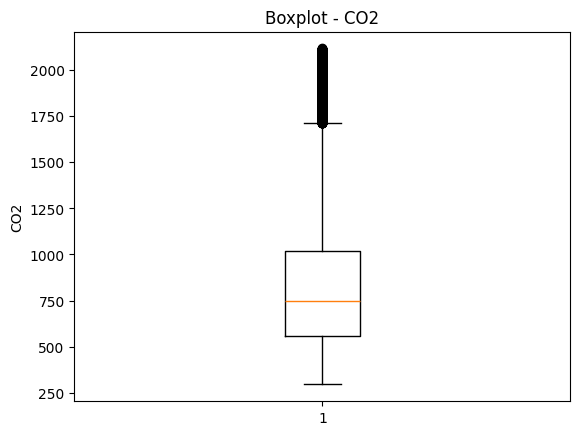

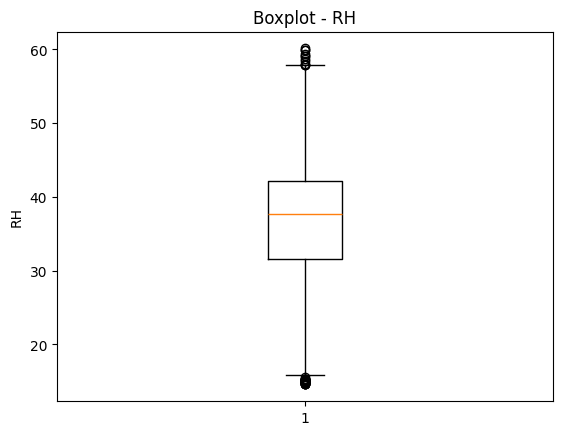

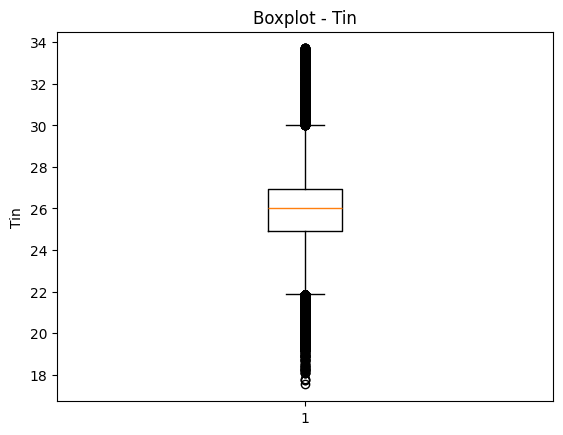

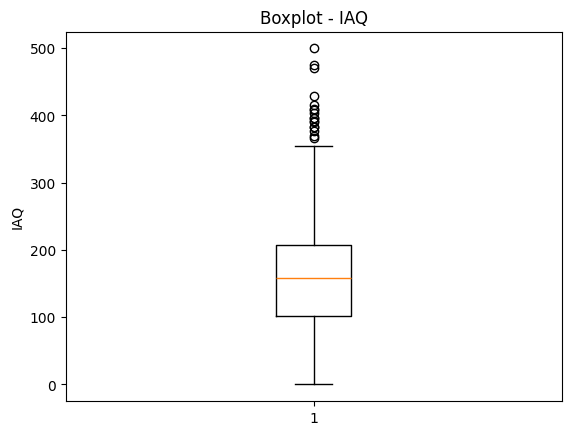

In [ ]:
# Boxplot visualization (outliers appear automatically).
import matplotlib.pyplot as plt

cols = ['CO2', 'RH', 'Tin', 'OCCUPAN', 'IAQ']
cols = [c for c in cols if c in df.columns]

for c in cols:
    plt.figure()
    plt.boxplot(df[c].dropna())
    plt.title(f"Boxplot - {c}")
    plt.ylabel(c)
    plt.show()


In [ ]:
# Check duplicate rows.
df.duplicated().sum()


np.int64(6)

In [ ]:
# View duplicate rows.
df[df.duplicated(keep=False)].sort_values(df.columns.tolist()).head(20)


,OCCUPANCY,WINDOW,IAQ,CO2,RH,Tin,MONTH_NUM
19357,0,0,68.00,786.47,41.31,25.50,10
19358,0,0,68.00,786.47,41.31,25.50,10
137008,0,0,73.82,596.85,37.72,23.26,12
137013,0,0,73.82,596.85,37.72,23.26,12
39461,0,0,95.00,868.53,38.92,24.19,11
39462,0,0,95.00,868.53,38.92,24.19,11
37860,0,0,134.00,832.12,38.80,24.46,11
37863,0,0,134.00,832.12,38.80,24.46,11
88053,0,0,192.00,808.23,27.77,26.21,3
88061,0,0,192.00,808.23,27.77,26.21,3


In [ ]:
# Check invalid WINDOW values (should be 0 or 1).
invalid_window = ~df["WINDOW"].isin([0, 1]) & df["WINDOW"].notna()
invalid_window.sum()


np.int64(0)

In [ ]:
# Check negative OCCUPAN values (should be >= 0).
invalid_occupan = (df["OCCUPANCY"] < 0) & df["OCCUPANCY"].notna()
invalid_occupan.sum()


np.int64(0)

In [ ]:
# Check RH values outside [0, 100].
invalid_rh = ((df["RH"] < 0) | (df["RH"] > 100)) & df["RH"].notna()
invalid_rh.sum()


np.int64(0)

In [ ]:
# Check non-positive CO2 values (should be > 0).
invalid_co2 = (df["CO2"] <= 0) & df["CO2"].notna()
invalid_co2.sum()


np.int64(0)

In [ ]:
# Feature Engineering: CO2 interaction with occupancy (0/1).
df["CO2_x_OCCUPANCY"] = df["CO2"] * df["OCCUPANCY"]


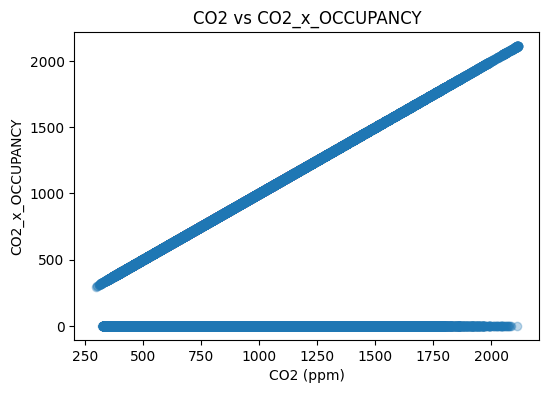

In [ ]:
import matplotlib.pyplot as plt

# Scatter بين CO2 والقيمة المتحولة
plt.figure(figsize=(6, 4))
plt.scatter(df["CO2"], df["CO2_x_OCCUPANCY"], alpha=0.3)
plt.xlabel("CO2 (ppm)")
plt.ylabel("CO2_x_OCCUPANCY")
plt.title("CO2 vs CO2_x_OCCUPANCY")
plt.show()


/tmp/ipython-input-75785190.py:5: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([empty, occupied], labels=["Empty", "Occupied"])


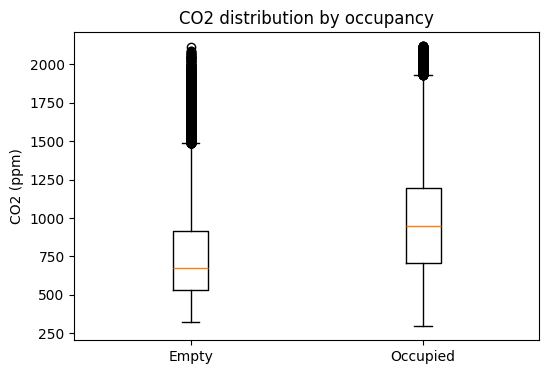

In [ ]:
occupied = df.loc[df["OCCUPANCY"] == 1, "CO2"]
empty = df.loc[df["OCCUPANCY"] == 0, "CO2"]

plt.figure(figsize=(6, 4))
plt.boxplot([empty, occupied], labels=["Empty", "Occupied"])
plt.ylabel("CO2 (ppm)")
plt.title("CO2 distribution by occupancy")
plt.show()


In [ ]:
# Feature Engineering: CO2 interaction with window status (0/1).
df["CO2_x_WINDOW"] = df["CO2"] * df["WINDOW"]


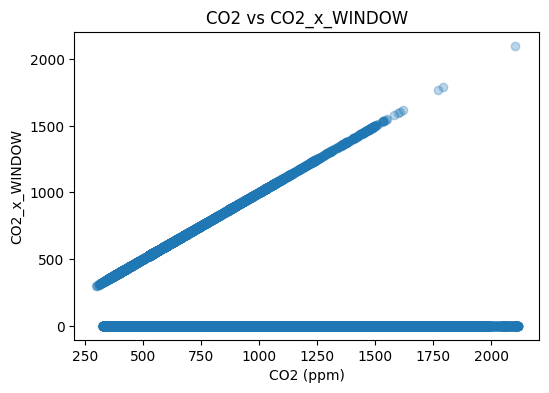

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 4))
plt.scatter(df["CO2"], df["CO2_x_WINDOW"], alpha=0.3)
plt.xlabel("CO2 (ppm)")
plt.ylabel("CO2_x_WINDOW")
plt.title("CO2 vs CO2_x_WINDOW")
plt.show()


/tmp/ipython-input-2870382560.py:5: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([closed_window, open_window], labels=["Closed", "Open"])


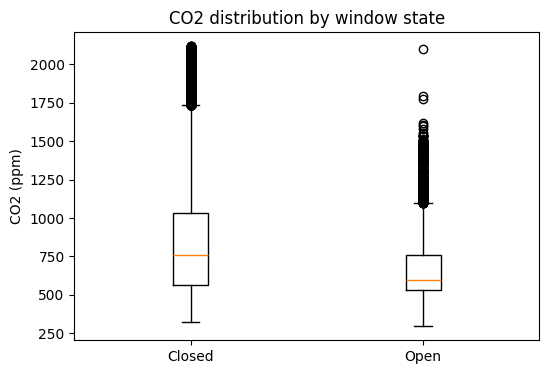

In [ ]:
open_window = df.loc[df["WINDOW"] == 1, "CO2"]
closed_window = df.loc[df["WINDOW"] == 0, "CO2"]

plt.figure(figsize=(6, 4))
plt.boxplot([closed_window, open_window], labels=["Closed", "Open"])
plt.ylabel("CO2 (ppm)")
plt.title("CO2 distribution by window state")
plt.show()


In [ ]:
# Feature Engineering: combined window and occupancy indicator.
df["WINDOW_x_OCCUPANCY"] = df["WINDOW"] * df["OCCUPANCY"]


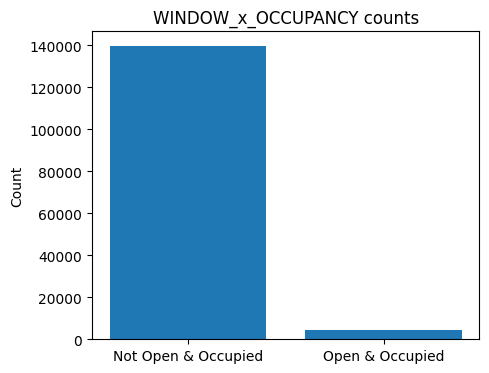

In [ ]:
import matplotlib.pyplot as plt

# عدّ الحالات المختلفة (0 أو 1)
counts = df["WINDOW_x_OCCUPANCY"].value_counts().sort_index()

plt.figure(figsize=(5, 4))
plt.bar(counts.index, counts.values)
plt.xticks([0, 1], ["Not Open & Occupied", "Open & Occupied"])
plt.ylabel("Count")
plt.title("WINDOW_x_OCCUPANCY counts")
plt.show()


In [ ]:
# Feature Engineering: simple comfort proxy using temperature and humidity.
df["Temp_x_RH"] = df["Tin"] * df["RH"]


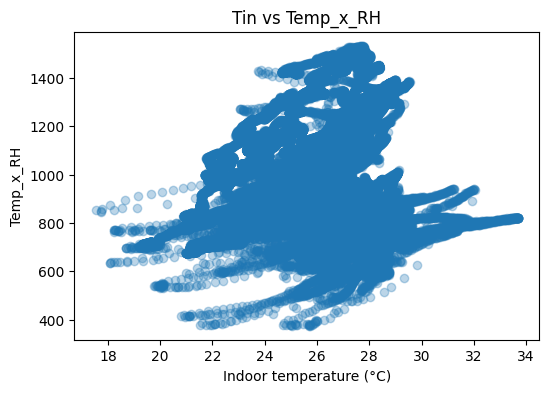

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 4))
plt.scatter(df["Tin"], df["Temp_x_RH"], alpha=0.3)
plt.xlabel("Indoor temperature (°C)")
plt.ylabel("Temp_x_RH")
plt.title("Tin vs Temp_x_RH")
plt.show()


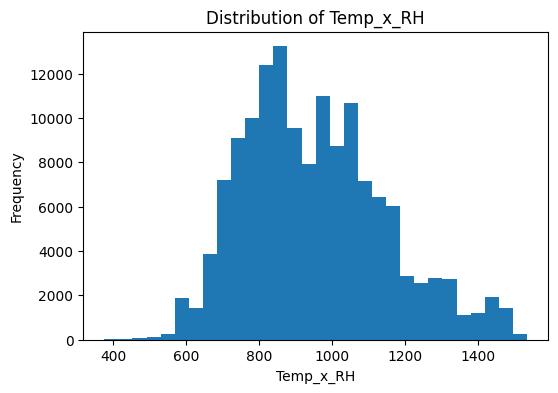

In [ ]:
plt.figure(figsize=(6, 4))
plt.hist(df["Temp_x_RH"].dropna(), bins=30)
plt.xlabel("Temp_x_RH")
plt.ylabel("Frequency")
plt.title("Distribution of Temp_x_RH")
plt.show()


In [ ]:
df.head()

,OCCUPANCY,WINDOW,IAQ,CO2,RH,Tin,MONTH_NUM,CO2_x_OCCUPANCY,CO2_x_WINDOW,WINDOW_x_OCCUPANCY,Temp_x_RH
0,0,0,72.40,404.25,53.45,26.18,9,0.0,0.0,0,1399.3210
1,0,0,73.05,404.07,53.45,26.18,9,0.0,0.0,0,1399.3210
2,0,0,74.08,404.07,53.45,26.18,9,0.0,0.0,0,1399.3210
3,0,0,72.27,406.42,53.42,26.18,9,0.0,0.0,0,1398.5356
4,0,0,73.98,407.35,53.45,26.17,9,0.0,0.0,0,1398.7865


In [ ]:
# Noise check: invalid occupancy values (should be 0 or 1).
invalid_occ = ~df["OCCUPANCY"].isin([0, 1]) & df["OCCUPANCY"].notna()
invalid_occ.sum()


np.int64(0)

In [ ]:
# Noise check: invalid occupancy values (should be 0 or 1).
invalid_occ = ~df["WINDOW"].isin([0, 1]) & df["WINDOW"].notna()
invalid_occ.sum()


np.int64(0)

In [ ]:
# Noise check: RH values outside [0, 100].
invalid_rh = ((df["RH"] < 0) | (df["RH"] > 100)) & df["RH"].notna()
invalid_rh.sum()


np.int64(0)

In [ ]:
# Noise check: non-positive CO2 values (should be > 0).
invalid_co2 = (df["CO2"] <= 0) & df["CO2"].notna()
invalid_co2.sum()


np.int64(0)

In [ ]:
# Noise check: Tin values outside a reasonable indoor range [-10, 60].
invalid_tin = ((df["Tin"] < -10) | (df["Tin"] > 60)) & df["Tin"].notna()
invalid_tin.sum()


np.int64(0)

In [ ]:
# Noise check: IAQ values outside [0, 500].
invalid_iaq = ((df["IAQ"] < 0) | (df["IAQ"] > 500)) & df["IAQ"].notna()
invalid_iaq.sum()


np.int64(0)

In [ ]:
import numpy as np

df["Air_Quality_Label"] = np.select(
    [
        df["IAQ"] <= 100,
        (df["IAQ"] > 100) & (df["IAQ"] <= 200),
        df["IAQ"] > 200
    ],
    ["Good", "Moderate", "Poor"],
    default="Unknown"   # مهم يكون نص مش np.nan
)

# check
df["Air_Quality_Label"].value_counts()


,count
Air_Quality_Label,
Moderate,66942
Poor,41740
Good,35318


In [ ]:
(df["Air_Quality_Label"] == "Unknown").sum()


np.int64(0)

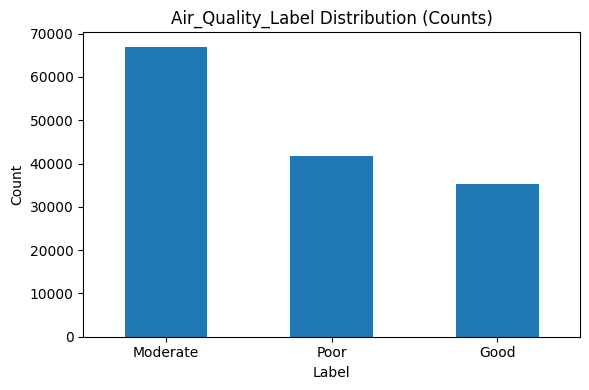

In [ ]:
import matplotlib.pyplot as plt

counts = df["Air_Quality_Label"].value_counts()

plt.figure(figsize=(6,4))
counts.plot(kind="bar")
plt.title("Air_Quality_Label Distribution (Counts)")
plt.xlabel("Label")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


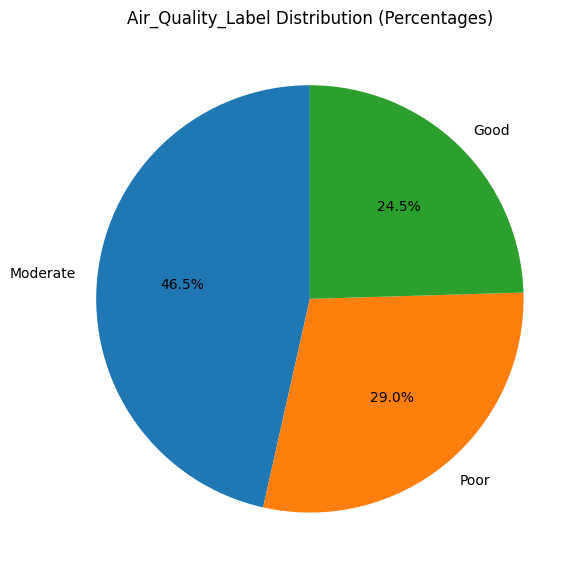

In [ ]:
import matplotlib.pyplot as plt

counts = df["Air_Quality_Label"].value_counts()

plt.figure(figsize=(6,6))
plt.pie(counts.values, labels=counts.index, autopct="%1.1f%%", startangle=90)
plt.title("Air_Quality_Label Distribution (Percentages)")
plt.tight_layout()
plt.show()


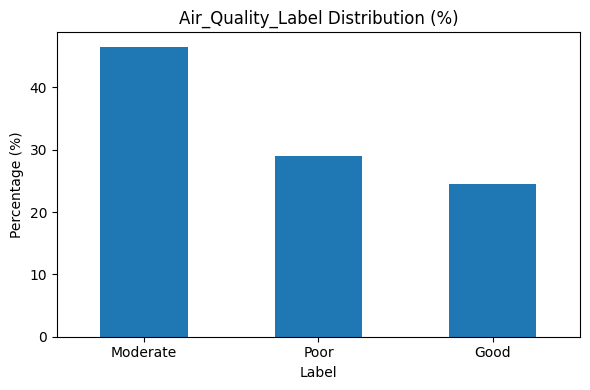

In [ ]:
import matplotlib.pyplot as plt

percent = df["Air_Quality_Label"].value_counts(normalize=True) * 100

plt.figure(figsize=(6,4))
percent.plot(kind="bar")
plt.title("Air_Quality_Label Distribution (%)")
plt.xlabel("Label")
plt.ylabel("Percentage (%)")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()
